In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Imports and Liabraries


In [ ]:
import os
import math
import numpy as np
import random
from PIL import Image,ImageEnhance

# Keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import  VGG16,MobileNetV2,EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.utils import shuffle

#Load Datasets


In [ ]:
train_dir = '/content/drive/MyDrive/brain_tumor_mris/Training'
test_dir = '/content/drive/MyDrive/final_test/Testing'
val_dir = '/content/drive/MyDrive/brain_tumor_mris/Validation'
train_paths = []
train_labels =[]

classes = ['notumor', 'pituitary', 'meningioma', 'glioma']

for label in classes:
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths,train_labels = shuffle(train_paths,train_labels)

test_paths = []
test_labels =[]

for label in classes:
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths,test_labels = shuffle(test_paths,test_labels)

val_paths = []
val_labels = []

for label in classes:
    for image in os.listdir(os.path.join(val_dir, label)):
        val_paths.append(os.path.join(val_dir, label, image))
        val_labels.append(label)

val_paths, val_labels = shuffle(val_paths, val_labels)

#Data Visualisation




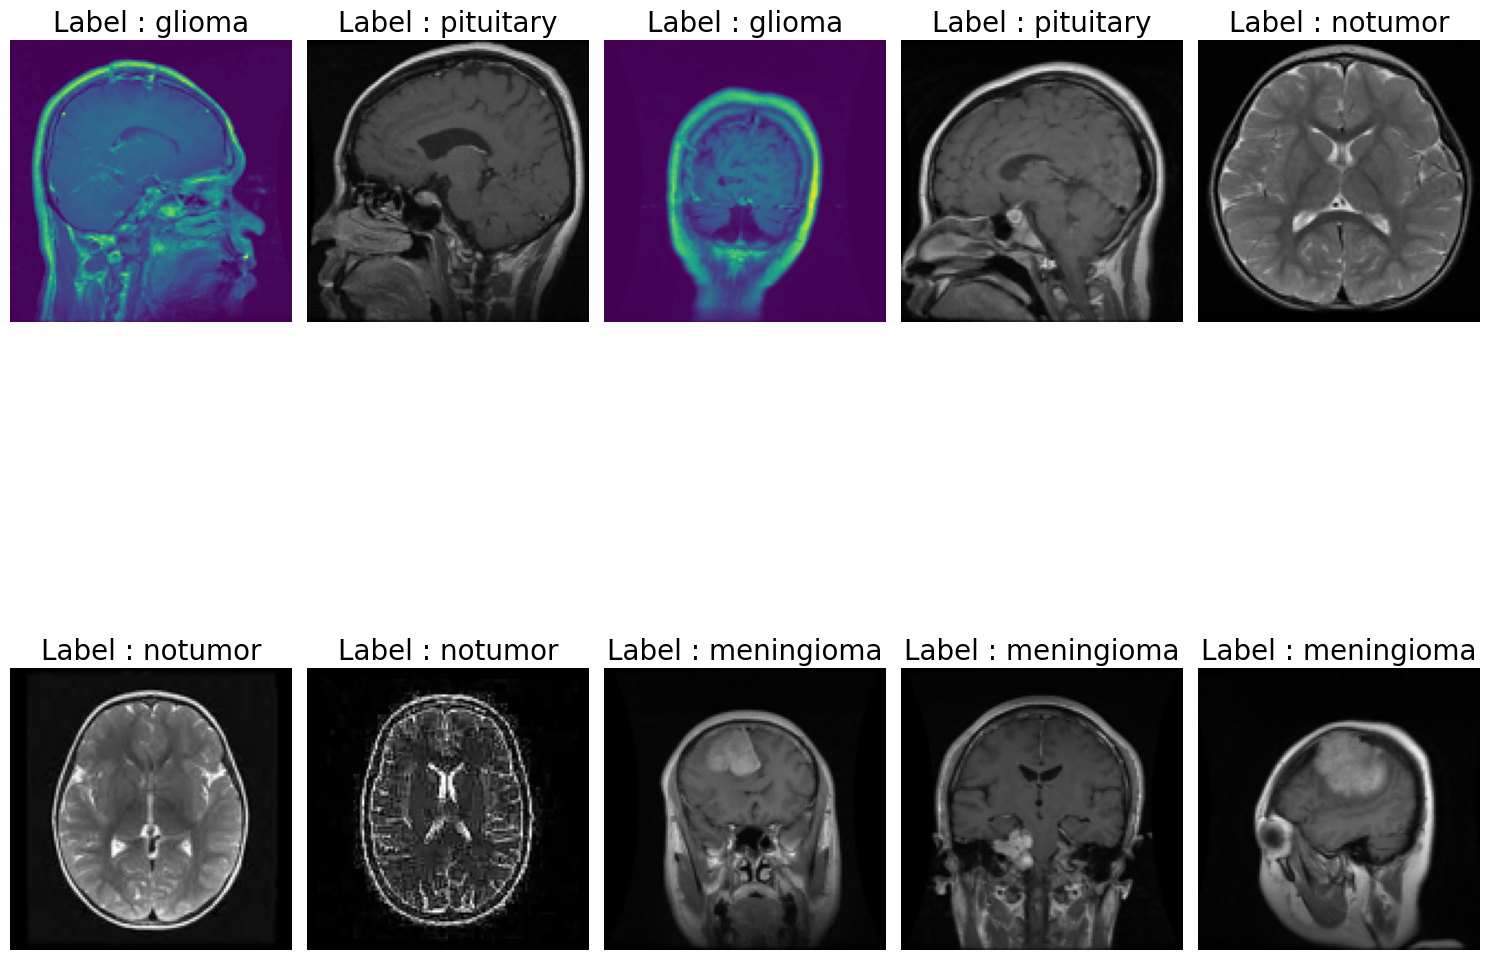

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

random_indices = random.sample(range(len(train_paths)),10)


fig,axes = plt.subplots(2,5, figsize= (15,16))
axes = axes.ravel()

for i,idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))

  # dispaly images

  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label : {train_labels[idx]}" , fontsize=20)

plt.tight_layout()
plt.show()


# Image preprocessing

In [ ]:
"""# Image preprocessing"""

# Image Augmented Function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast

    # Add horizontal flip augmentation
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# notumor = 0
# gioma =1
# meningioma=2
# pituitary=3

label_mapping = {
    'notumor': 0,
    'pituitary': 1,
    'meningioma': 2,
    'glioma': 3
}

def encode_label(labels):
    encoded = [label_mapping[label] for label in labels]
    return np.array(encoded)

def open_images_no_aug(paths):
    images = []

    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image)
        image = image / 255.0
        images.append(image)

    return np.array(images)



def datagen_val(paths, labels, batch_size=12):
  while True:
      for i in range(0, len(paths), batch_size):
          batch_paths = paths[i:i + batch_size]
          batch_images = open_images_no_aug(batch_paths)

          batch_labels = labels[i:i + batch_size]
          batch_labels = encode_label(batch_labels)

          yield batch_images, batch_labels

#data generator for batching

def datagen(paths, labels, batch_size=20):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)

            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)

            yield batch_images, batch_labels

#VGG16 Model Architecture

In [ ]:
#model Architecture

IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze the early feature extraction layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the final convolutional block layers for medical feature fine-tuning
base_model.layers[-2].trainable = True  # Convolutional layer
base_model.layers[-3].trainable = True  # Convolutional layer
base_model.layers[-4].trainable = True  # Convolutional layer
base_model.layers[-5].trainable = True  # Convolutional layer

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(len(classes), activation='softmax'))

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Parameters
batch_size = 20
steps = math.ceil(len(train_paths) / batch_size)
val_steps = math.ceil(len(val_paths) / batch_size)

epochs = 30

# Train model
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=datagen_val(val_paths, val_labels, batch_size=batch_size),
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 1.0417 - sparse_categorical_accuracy: 0.5686
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.77951, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - loss: 0.7354 - sparse_categorical_accuracy: 0.7087 - val_loss: 0.6071 - val_sparse_categorical_accuracy: 0.7795
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.3929 - sparse_categorical_accuracy: 0.8639
Epoch 2: val_sparse_categorical_accuracy improved from 0.77951 to 0.83681, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - loss: 0.3592 - sparse_categorical_accuracy: 0.8739 - val_loss: 0.4572 - val_sparse_categorical_accuracy: 0.8368
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.2678 - sparse_categorical_accuracy: 0.9080
Epoch 3: val_sparse_categorical_accuracy did n

#VGG16 Train Vs val plots


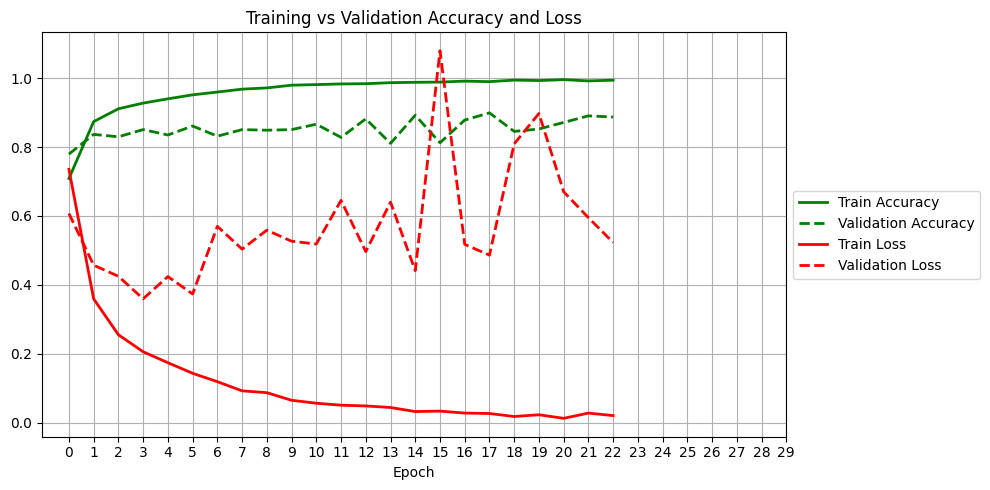

In [ ]:
plt.figure(figsize=(10, 5))
plt.grid(True)

# Accuracy
plt.plot(history.history['sparse_categorical_accuracy'],
         'g-', linewidth=2, label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'],
         'g--', linewidth=2, label='Validation Accuracy')

# Loss
plt.plot(history.history['loss'],
         'r-', linewidth=2, label='Train Loss')
plt.plot(history.history['val_loss'],
         'r--', linewidth=2, label='Validation Loss')

plt.title("Training vs Validation Accuracy and Loss")
plt.xlabel("Epoch")
plt.xticks(range(epochs))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#VGG16 model classificationn report

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       144
           1       0.97      0.99      0.98       144
           2       0.88      0.99      0.93       144
           3       0.98      0.74      0.85       144

    accuracy                           0.93       576
   macro avg       0.93      0.93      0.93       576
weighted avg       0.93      0.93      0.93       576



#VGG16 Model confusion Matrics

Confusion Matrix:
[[144   0   0   0]
 [  1 142   1   0]
 [  0   0 142   2]
 [ 15   4  18 107]]


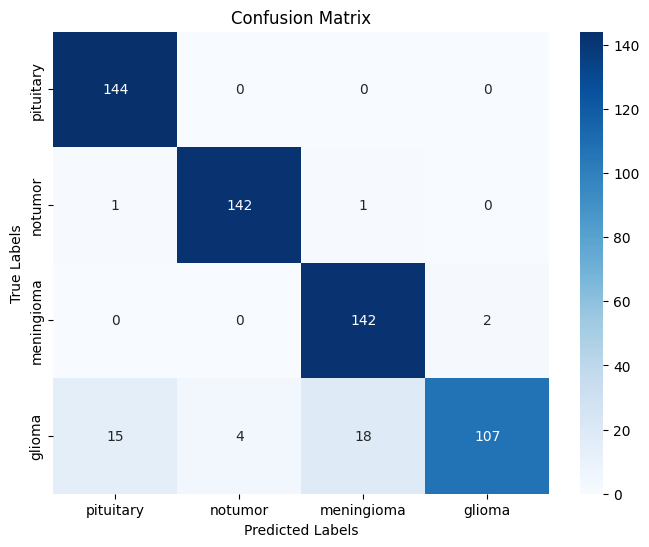

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)


# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#VGG16 Save & Load Model

In [ ]:
# Save the entire model
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

#MRI Tumor Detection System

In [ ]:

from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# MUST match label_mapping used during training
# notumor = 0
# pituitary = 1
# meningioma = 2
# glioma = 3
class_labels = ['notumor', 'pituitary', 'meningioma', 'glioma']

def detect_and_display(img_path, model, image_size=128):
    try:
        # Load image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img)
        img_array = img_array.astype("float32") / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        predictions = model.predict(img_array, verbose=0)

        predicted_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_index]

        print("Raw Prediction:", predictions[0])
        print("Predicted Index:", predicted_index)
        print("Predicted Class:", class_labels[predicted_index])

        # Display result
        if class_labels[predicted_index] == "notumor":
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_index]}"

        plt.figure(figsize=(6,6))
        plt.imshow(load_img(img_path))
        plt.axis("off")
        plt.title(f"{result}\nConfidence: {confidence*100:.2f}%")
        plt.show()

    except Exception as e:
        print("Error:", e)

# vgg16 testing single photos

Raw Prediction: [5.8498416e-15 6.0055753e-19 1.0000000e+00 4.4210331e-16]
Predicted Index: 2
Predicted Class: meningioma


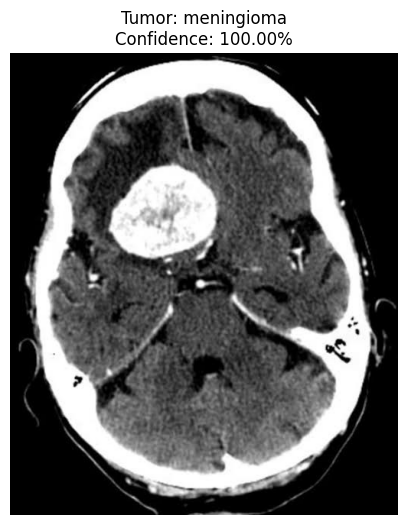

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/meningioma/Te-me_0015.jpg' # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [8.0180307e-09 2.1181294e-09 6.1075117e-10 1.0000000e+00]
Predicted Index: 3
Predicted Class: glioma


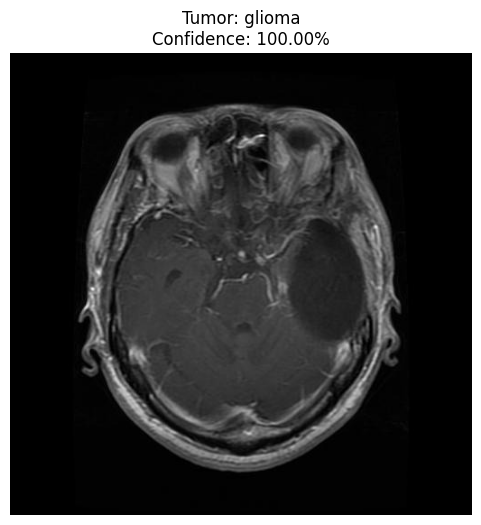

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/glioma/Te-gl_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [1.00000000e+00 5.44874645e-10 1.40244945e-08 1.54544655e-10]
Predicted Index: 0
Predicted Class: notumor


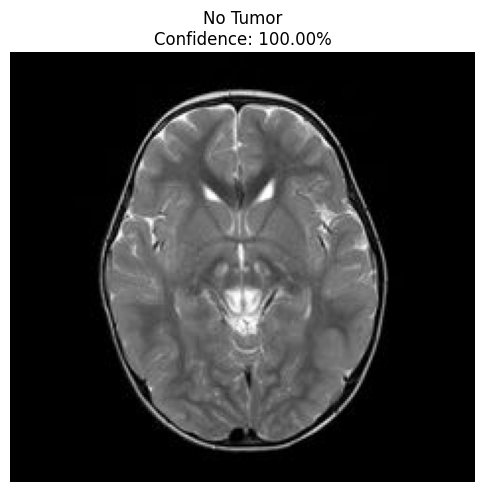

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/notumor/Te-no_0016.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [2.5730020e-07 9.9997985e-01 1.9618567e-05 2.6281876e-07]
Predicted Index: 1
Predicted Class: pituitary


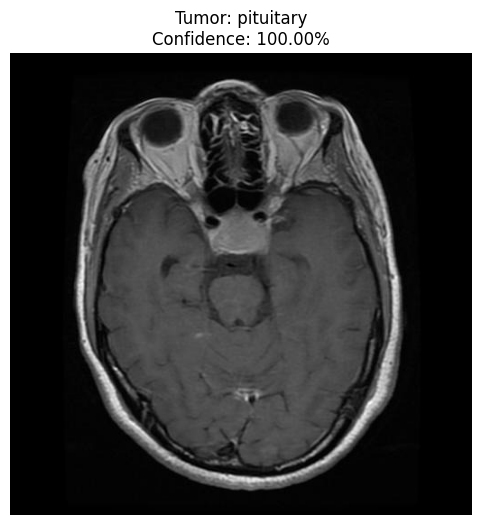

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/pituitary/Te-pi_0016.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [ ]:
print(len(train_paths))
print(len(val_paths))
print(len(test_paths))

4672
576
576


In [ ]:
print(label_mapping)
print(classes)


{'notumor': 0, 'pituitary': 1, 'meningioma': 2, 'glioma': 3}
['notumor', 'pituitary', 'meningioma', 'glioma']


In [ ]:
from collections import Counter

print("Train:", Counter(train_labels))
print("Validation:", Counter(val_labels))
print("Test:", Counter(test_labels))

Train: Counter({'pituitary': 1168, 'glioma': 1168, 'notumor': 1168, 'meningioma': 1168})
Validation: Counter({'meningioma': 144, 'notumor': 144, 'pituitary': 144, 'glioma': 144})
Test: Counter({'glioma': 144, 'pituitary': 144, 'meningioma': 144, 'notumor': 144})


In [ ]:
from tensorflow.keras.models import load_model

saved_model = load_model("best_model.keras")

loss1, acc1 = model.evaluate(
    datagen_val(test_paths, test_labels, batch_size=20),
    steps=len(test_paths)//20,
    verbose=0
)

loss2, acc2 = saved_model.evaluate(
    datagen_val(test_paths, test_labels, batch_size=20),
    steps=len(test_paths)//20,
    verbose=0
)

print("Current model:", acc1)
print("Saved model:", acc2)

Current model: 0.9267857074737549
Saved model: 0.9267857074737549


# MobilNetV2

# MobileNetv2 Model Architecture


In [ ]:
IMAGE_SIZE = 128

# Load MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the final convolutional block layers for medical feature fine-tuning
base_model.layers[-2].trainable = True  # Convolutional layer
base_model.layers[-3].trainable = True  # Convolutional layer
base_model.layers[-4].trainable = True  # Convolutional layer
base_model.layers[-5].trainable = True  # Convolutional layer

# Build model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(len(classes), activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_mobilenet.keras',
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

batch_size = 20
steps = math.ceil(len(train_paths) / batch_size)
val_steps = math.ceil(len(val_paths) / batch_size)

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    epochs=30,
    steps_per_epoch=steps,
    validation_data=datagen_val(val_paths, val_labels, batch_size=batch_size),
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 1.1539 - sparse_categorical_accuracy: 0.5413
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.79514, saving model to best_mobilenet.keras

Epoch 1: finished saving model to best_mobilenet.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 57s 194ms/step - loss: 0.8590 - sparse_categorical_accuracy: 0.6678 - val_loss: 0.5130 - val_sparse_categorical_accuracy: 0.7951
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.5263 - sparse_categorical_accuracy: 0.8020
Epoch 2: val_sparse_categorical_accuracy improved from 0.79514 to 0.80556, saving model to best_mobilenet.keras

Epoch 2: finished saving model to best_mobilenet.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - loss: 0.4790 - sparse_categorical_accuracy: 0.8251 - val_loss: 0.4860 - val_sparse_categorical_accuracy: 0.8056
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.3975 - sparse_categorical_accuracy: 0.8570
Epoch 3: val_sparse_categorica

# MobileNetv2 train vs val

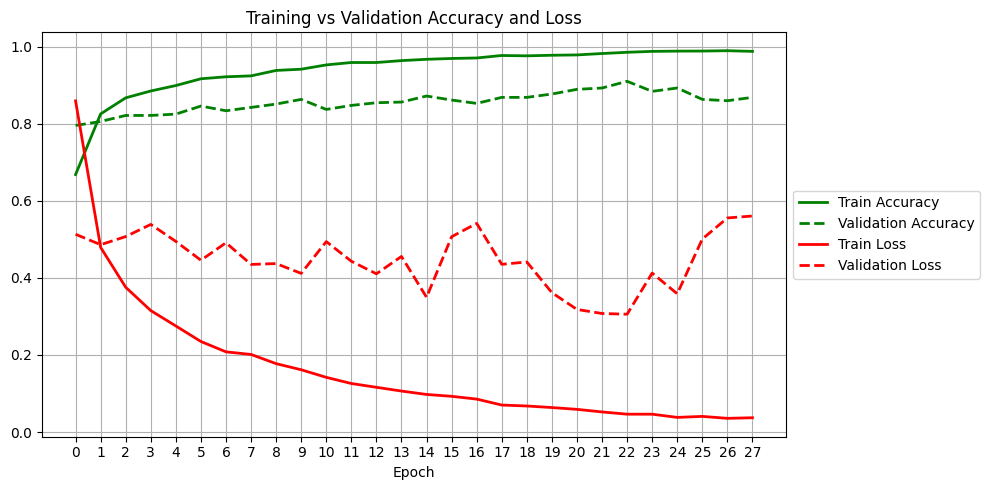

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.grid(True)

# Accuracy
plt.plot(history.history['sparse_categorical_accuracy'],
         'g-', linewidth=2, label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'],
         'g--', linewidth=2, label='Validation Accuracy')

# Loss
plt.plot(history.history['loss'],
         'r-', linewidth=2, label='Train Loss')
plt.plot(history.history['val_loss'],
         'r--', linewidth=2, label='Validation Loss')

plt.title("Training vs Validation Accuracy and Loss")
plt.xlabel("Epoch")

# Number of epochs actually completed
num_epochs = len(history.history['loss'])
plt.xticks(range(num_epochs))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# Mobilenetv2 classification report

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       144
           1       0.98      0.99      0.99       144
           2       0.87      0.94      0.90       144
           3       0.97      0.77      0.86       144

    accuracy                           0.93       576
   macro avg       0.93      0.93      0.92       576
weighted avg       0.93      0.93      0.92       576



#Mobilenetv2 confusion Matrix

Confusion Matrix:
[[144   0   0   0]
 [  1 143   0   0]
 [  4   2 135   3]
 [ 11   1  21 111]]


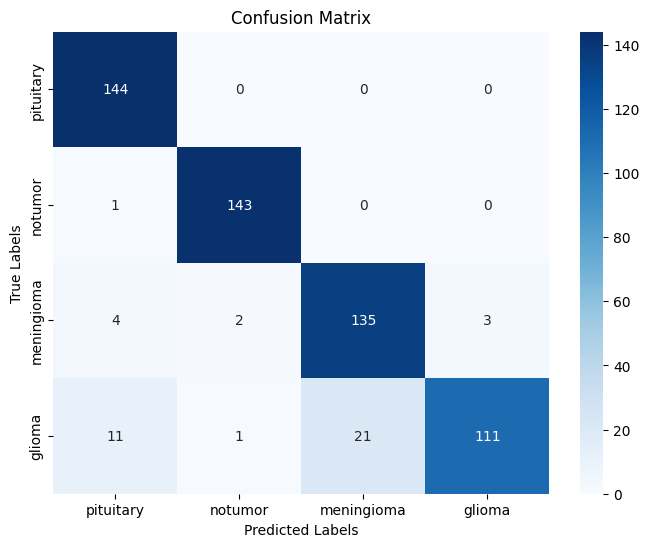

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)


# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#MobileNet Save & Load Model

In [ ]:
model.save("mobilenet_brain_tumor.h5")

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('mobilenet_brain_tumor.h5')

# Mobile_net testing single photos

Raw Prediction: [2.0427546e-04 8.9254151e-08 9.9979520e-01 4.4334550e-07]
Predicted Index: 2
Predicted Class: meningioma


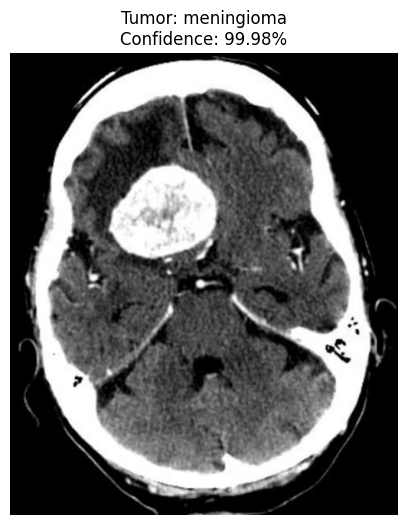

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/meningioma/Te-me_0015.jpg' # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [3.3147295e-04 4.1475092e-04 9.9920344e-01 5.0324667e-05]
Predicted Index: 2
Predicted Class: meningioma


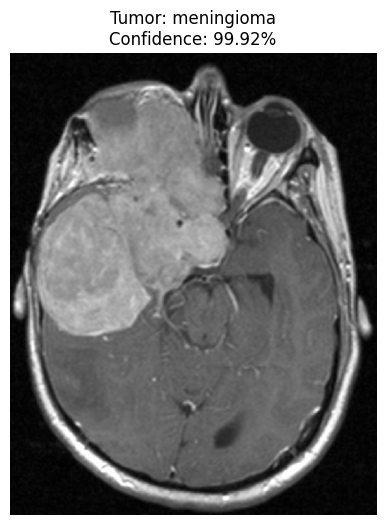

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/meningioma/Te-me_0018.jpg' # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [8.102146e-05 9.991621e-01 7.524960e-04 4.440777e-06]
Predicted Index: 1
Predicted Class: pituitary


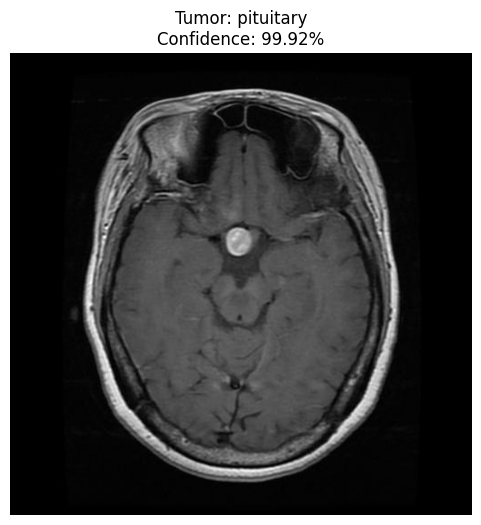

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/pituitary/Te-pi_0018.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [9.5600849e-03 4.4274639e-04 3.4247672e-03 9.8657238e-01]
Predicted Index: 3
Predicted Class: glioma


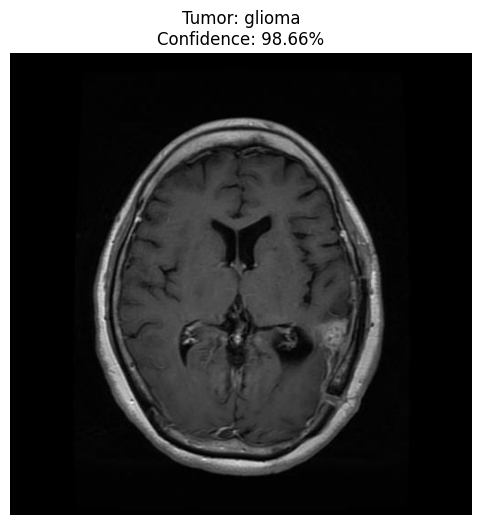

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/glioma/Te-gl_0019.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [9.9961650e-01 2.0052851e-06 2.1145497e-04 1.7002280e-04]
Predicted Index: 0
Predicted Class: notumor


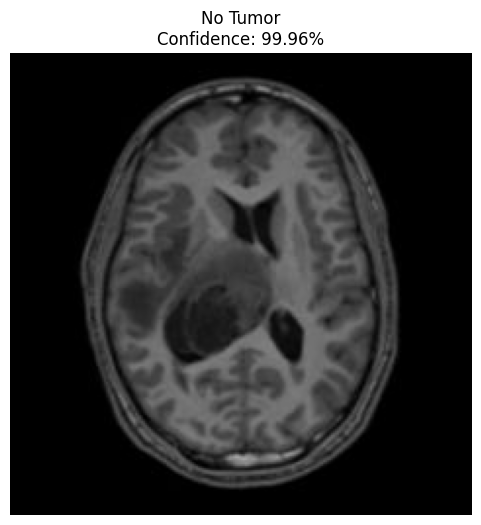

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/notumor/Te-no_0020.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

# Efficient Net B0

#Efficient Net B0 Data preprocessing

In [ ]:
"""# Image preprocessing"""

def augment_image(image):
    image = Image.fromarray(np.uint8(image))

    # Random brightness
    image = ImageEnhance.Brightness(image).enhance(
        random.uniform(0.8, 1.2)
    )

    # Random contrast
    image = ImageEnhance.Contrast(image).enhance(
        random.uniform(0.8, 1.2)
    )

    # Random horizontal flip
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

    image = np.array(image)

    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# notumor = 0
# gioma =1
# meningioma=2
# pituitary=3

label_mapping = {
    'notumor': 0,
    'pituitary': 1,
    'meningioma': 2,
    'glioma': 3
}

def encode_label(labels):
    encoded = [label_mapping[label] for label in labels]
    return np.array(encoded)

def open_images_no_aug(paths):
    images = []

    for path in paths:
        image = load_img(
            path,
            target_size=(IMAGE_SIZE, IMAGE_SIZE)
        )

        image = img_to_array(image)
        images.append(image)

    return np.array(images)



def datagen_val(paths, labels, batch_size=12):
  while True:
      for i in range(0, len(paths), batch_size):
          batch_paths = paths[i:i + batch_size]
          batch_images = open_images_no_aug(batch_paths)

          batch_labels = labels[i:i + batch_size]
          batch_labels = encode_label(batch_labels)

          yield batch_images, batch_labels

#data generator for batching

def datagen(paths, labels, batch_size=20):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)

            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)

            yield batch_images, batch_labels

# EfficientNetB0 Model Architecture

In [ ]:
IMAGE_SIZE = 128

# Load EfficientNetB0
base_model = EfficientNetB0(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the final convolutional block layers for medical feature fine-tuning
base_model.layers[-2].trainable = True  # Convolutional layer
base_model.layers[-3].trainable = True  # Convolutional layer
base_model.layers[-4].trainable = True  # Convolutional layer
base_model.layers[-5].trainable = True  # Convolutional layer

# Build model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(len(classes), activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_EfficientNetB0.keras',
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

batch_size = 20
steps = math.ceil(len(train_paths) / batch_size)
val_steps = math.ceil(len(val_paths) / batch_size)

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size),
    epochs=50,
    steps_per_epoch=steps,
    validation_data=datagen_val(val_paths, val_labels, batch_size=batch_size),
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 1.2725 - sparse_categorical_accuracy: 0.4335
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.68924, saving model to best_EfficientNetB0.keras

Epoch 1: finished saving model to best_EfficientNetB0.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 72s 195ms/step - loss: 1.0567 - sparse_categorical_accuracy: 0.5582 - val_loss: 0.7530 - val_sparse_categorical_accuracy: 0.6892
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.7050 - sparse_categorical_accuracy: 0.7353
Epoch 2: val_sparse_categorical_accuracy improved from 0.68924 to 0.72917, saving model to best_EfficientNetB0.keras

Epoch 2: finished saving model to best_EfficientNetB0.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.6647 - sparse_categorical_accuracy: 0.7513 - val_loss: 0.6630 - val_sparse_categorical_accuracy: 0.7292
Epoch 3/50
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.5751 - sparse_categorical_accuracy: 0.7854
Epoch 3: val_

# efficientNetB0 Train vs val

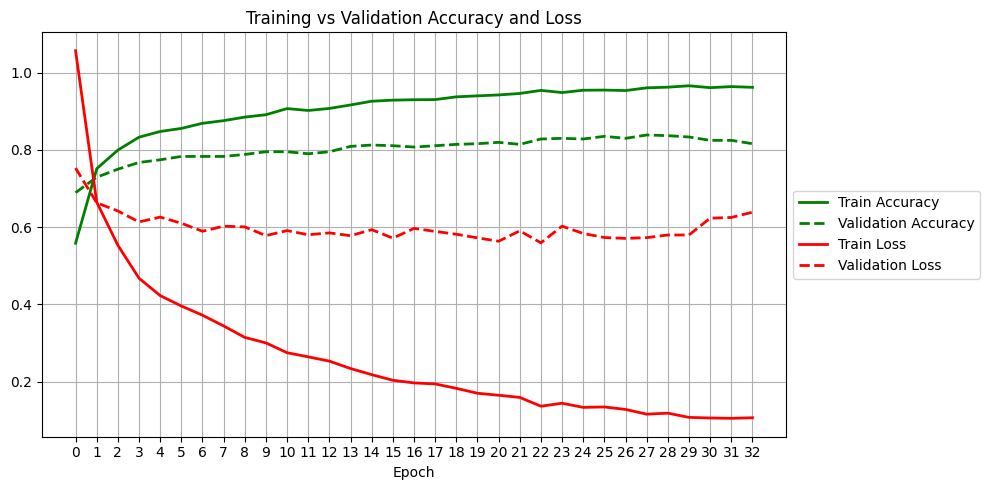

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.grid(True)

# Accuracy
plt.plot(history.history['sparse_categorical_accuracy'],
         'g-', linewidth=2, label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'],
         'g--', linewidth=2, label='Validation Accuracy')

# Loss
plt.plot(history.history['loss'],
         'r-', linewidth=2, label='Train Loss')
plt.plot(history.history['val_loss'],
         'r--', linewidth=2, label='Validation Loss')

plt.title("Training vs Validation Accuracy and Loss")
plt.xlabel("Epoch")

# Number of epochs actually completed
num_epochs = len(history.history['loss'])
plt.xticks(range(num_epochs))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# efficientnetb0 Classification Report

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images_no_aug(test_paths)
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       144
           1       0.95      0.98      0.97       144
           2       0.78      0.92      0.84       144
           3       0.91      0.64      0.75       144

    accuracy                           0.88       576
   macro avg       0.89      0.88      0.88       576
weighted avg       0.89      0.88      0.88       576



#efficientnetB0 Confusion Matrix

Confusion Matrix:
[[144   0   0   0]
 [  1 141   1   1]
 [  2   2 132   8]
 [ 11   5  36  92]]


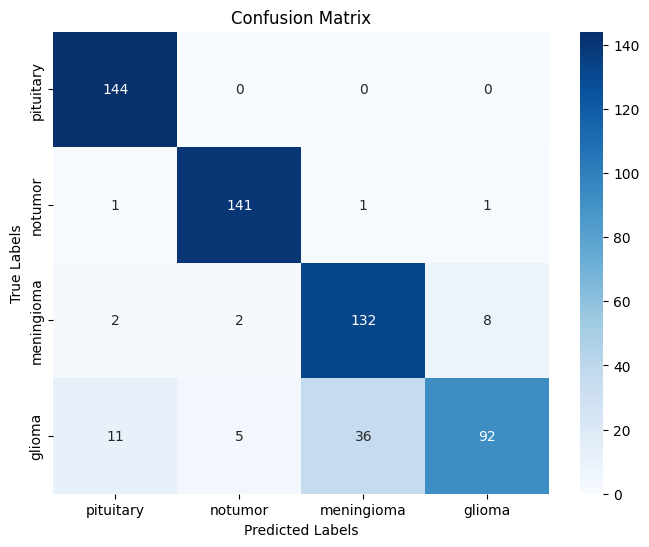

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)


# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#EfficientNet Save & Load Model

In [ ]:
model.save("efficient_net_brain_tumor.h5")

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('efficient_net_brain_tumor.h5')

#efficient_net MRI Tumor Detection System

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

class_labels = ['notumor', 'pituitary', 'meningioma', 'glioma']


def detect_and_display(img_path, model, image_size=128):
    try:
        # Load image
        img = load_img(
            img_path,
            target_size=(image_size, image_size)
        )

        img_array = img_to_array(img)
        img_array = img_array.astype("float32")

        # IMPORTANT:
        # Do NOT divide by 255 for standard Keras EfficientNetB0
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        predictions = model.predict(img_array, verbose=0)

        predicted_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_index]

        print("Raw Prediction:", predictions[0])
        print("Predicted Index:", predicted_index)
        print("Predicted Class:", class_labels[predicted_index])

        if class_labels[predicted_index] == "notumor":
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_index]}"

        plt.figure(figsize=(6, 6))
        plt.imshow(load_img(img_path))
        plt.axis("off")
        plt.title(
            f"{result}\nConfidence: {confidence * 100:.2f}%"
        )
        plt.show()

    except Exception as e:
        print("Error:", e)

#efficient net b0 single photo testing

Raw Prediction: [0.0571341  0.14532384 0.78233194 0.01521013]
Predicted Index: 2
Predicted Class: meningioma


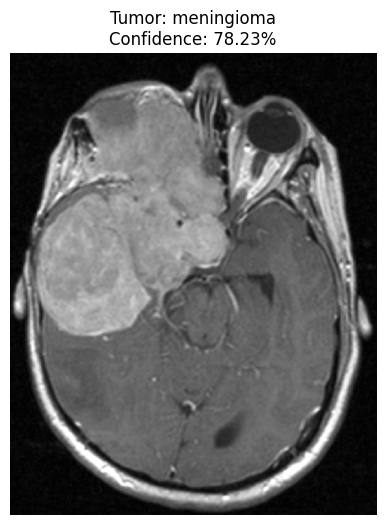

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/meningioma/Te-me_0018.jpg' # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [0.01720431 0.9375275  0.01909436 0.02617388]
Predicted Index: 1
Predicted Class: pituitary


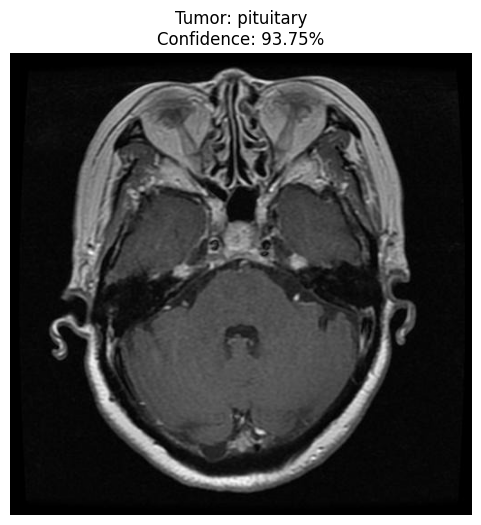

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/pituitary/Te-pi_0020.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [0.81798446 0.00203849 0.16040763 0.01956946]
Predicted Index: 0
Predicted Class: notumor


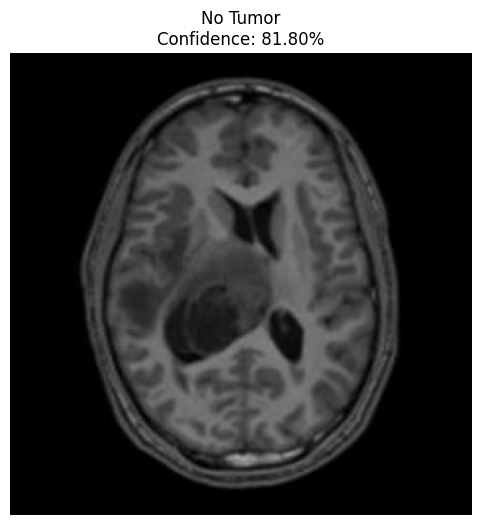

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/notumor/Te-no_0020.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

Raw Prediction: [0.2856528  0.00958452 0.15499279 0.5497699 ]
Predicted Index: 3
Predicted Class: glioma


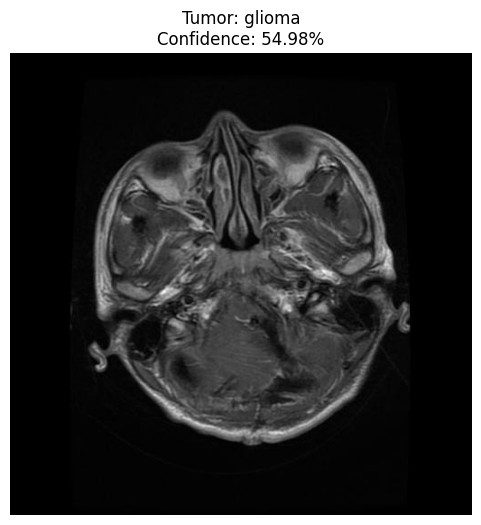

In [ ]:
image_path = '/content/drive/MyDrive/brain_tumor_mris/Testing/glioma/Te-gl_0029.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)